# MADS Dataset Statistics Viewer

Paste the path to any generated MADS dataset CSV in cell 3 and run all cells to view its statistics.

In [1]:
import pandas as pd

In [2]:
# ── Set your dataset path here ────────────────────────────────────────────────
DATASET_PATH = "../datasets/mads_synthetic_dataset_3.csv"   # ← paste your CSV path here

In [3]:
df = pd.read_csv(DATASET_PATH)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns  ←  {DATASET_PATH}")
df.head()

Loaded 10,000 rows × 13 columns  ←  ../datasets/mads_synthetic_dataset_3.csv


,event_id,timestamp,machine,event_type,feature_1,feature_2,feature_3,feature_4,feature_5,ip_address,user_id,process,label
0,EVT-00001,2025-04-13 12:00:00.000000,machine1,execution_suspicious_process,0.6089,0.4587,1.0347,0.7039,0.6019,192.168.1.75,U1017,netstat.exe,malicious
1,EVT-00002,2025-04-13 12:01:01.563700,machine1,lateral_movement,0.1973,1.0347,1.0673,0.1014,0.7431,192.168.1.125,U1008,msiexec.exe,malicious
2,EVT-00003,2025-04-13 12:02:13.269421,machine1,normal_activity,0.4294,0.6387,0.7711,0.5158,0.6117,192.168.1.25,U1017,msiexec.exe,benign
3,EVT-00004,2025-04-13 12:02:47.705168,machine1,phishing_credential_stealer,0.7158,0.9808,1.1189,0.8179,0.6464,192.168.1.65,U1009,whoami.exe,malicious
4,EVT-00005,2025-04-13 12:03:23.701545,machine1,normal_activity,-0.0396,0.3416,0.9948,0.5987,0.8392,192.168.1.55,U1008,msiexec.exe,benign


In [4]:
def display_dataset_stats(df: pd.DataFrame) -> None:
    n = len(df)
    print("=" * 65)
    print(f"  Total events : {n}")
    print("-" * 65)
    print("  Label distribution:")
    for label, cnt in df["label"].value_counts().items():
        bar = "█" * int(cnt / n * 40)
        print(f"    {label:<12} {cnt:>5}  ({cnt/n*100:5.1f}%)  {bar}")
    print("-" * 65)
    print("  Events per machine (% malicious):")
    for machine in sorted(df["machine"].unique()):
        sub = df[df["machine"] == machine]
        mal = (sub["label"] == "malicious").sum()
        print(f"    {machine:<10} {len(sub):>5} events   {mal/len(sub)*100:5.1f}% malicious")
    print("-" * 65)
    print("  Top event types:")
    for et, cnt in df["event_type"].value_counts().head(6).items():
        print(f"    {et:<40} {cnt:>4}")
    print("=" * 65)

display_dataset_stats(df)

  Total events : 10000
-----------------------------------------------------------------
  Label distribution:
    malicious     6624  ( 66.2%)  ██████████████████████████
    benign        3376  ( 33.8%)  █████████████
-----------------------------------------------------------------
  Events per machine (% malicious):
    machine1    4066 events    79.7% malicious
    machine2    1190 events    75.6% malicious
    machine3     783 events    62.7% malicious
    machine4    3168 events    58.0% malicious
    machine5     793 events    19.5% malicious
-----------------------------------------------------------------
  Top event types:
    normal_activity                          3376
    execution_suspicious_process             1344
    phishing_credential_stealer              1059
    failed_login_attempts                     723
    download_suspicious_domain                722
    exploit_cve                               632


In [5]:
print("Feature means by label:")
df.groupby("label")[["feature_1", "feature_2", "feature_3", "feature_4", "feature_5"]].mean().round(3)

Feature means by label:


,feature_1,feature_2,feature_3,feature_4,feature_5
label,,,,,
benign,0.292,0.397,0.448,0.493,0.556
malicious,0.553,0.647,0.698,0.745,0.853


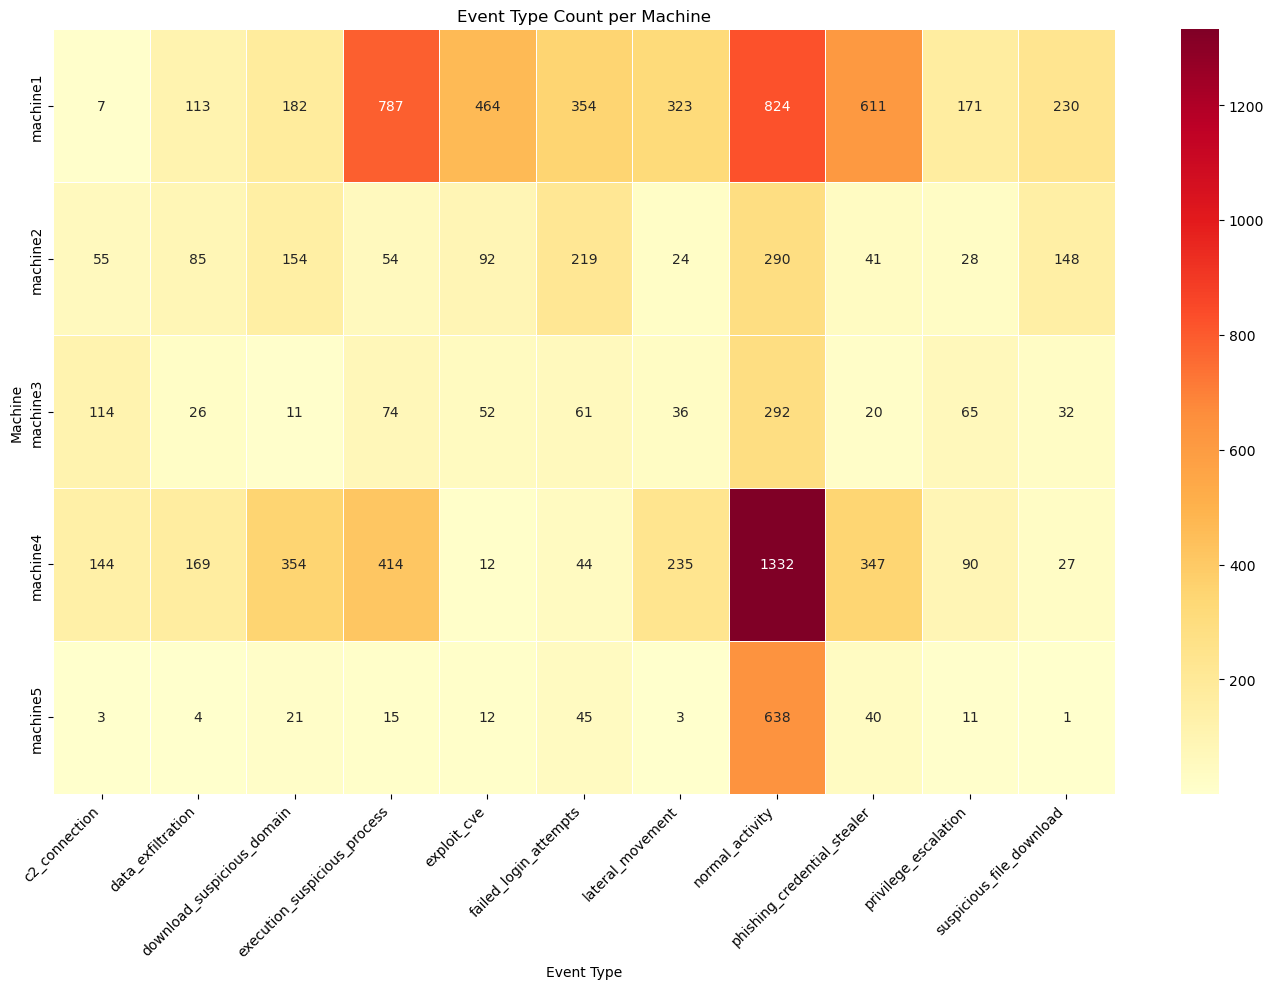

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot = df.groupby(["machine", "event_type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Event Type Count per Machine")
ax.set_xlabel("Event Type")
ax.set_ylabel("Machine")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [7]:
label_counts = (
    df.groupby(["event_type", "label"])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
    .sort_values("total", ascending=False)
)

print("Event type label distribution:")
label_counts


Event type label distribution:


label,benign,malicious,total
event_type,,,
normal_activity,3376,0,3376
execution_suspicious_process,0,1344,1344
phishing_credential_stealer,0,1059,1059
failed_login_attempts,0,723,723
download_suspicious_domain,0,722,722
exploit_cve,0,632,632
lateral_movement,0,621,621
suspicious_file_download,0,438,438
data_exfiltration,0,397,397
